## EDA of Boat Sales Data

### Import Libraries
Imports the required Python libraries, including `pandas` and `numpy` for data manipulation, and `seaborn` and `matplotlib` for data visualization.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns                       #visualisation
import matplotlib.pyplot as plt             #visualisation
%matplotlib inline     
sns.set(color_codes=True)

### Load Datasets
Reads the raw CSV files containing customer details, product details, sales channels, delivery partner data, and sales data into pandas DataFrames.

In [13]:
customers = pd.read_csv(r"C:\Users\hussa\Downloads\Boat Data\Customer_Details.csv")

products = pd.read_csv(r"C:\Users\hussa\Downloads\Boat Data\Product_Details.csv")

channels = pd.read_csv(r"C:\Users\hussa\Downloads\Boat Data\Sales_Channel.csv")

delivery = pd.read_csv(r"C:\Users\hussa\Downloads\Boat Data\Delivery_Partner_Data.csv")

sales = pd.read_csv(r"C:\Users\hussa\Downloads\Boat Data\Sales_Data.csv", low_memory=False)

### Examine Data Dimensions
Prints the shapes (number of rows and columns) of all imported DataFrames to understand their dimensions and scale.

In [14]:
print(customers.shape)
print(products.shape)
print(channels.shape)
print(delivery.shape)
print(sales.shape)

(150000, 11)
(106, 11)
(7, 6)
(180, 7)
(975000, 32)


### Merge DataFrames
Merges the primary sales DataFrame with customer, product, channel, and delivery partner details based on their respective ID keys, and displays the first few rows of the merged dataset.

In [15]:
merged_df = sales.merge(
    customers,
    on='CustomerID',
    how='left'
).merge(
    products,
    on='ProductID',
    how='left'
).merge(
    channels,
    on='ChannelID',
    how='left'
).merge(
    delivery,
    on='DeliveryPartnerID',
    how='left'
)

merged_df.head()

,SalesID,OrderDate,OrderHour,CustomerID,ProductID,ChannelID,DeliveryPartnerID,Quantity,GrossMRPValue,DiscountPct,...,ChannelType_y,ChannelScope,RegionScope,BaseShare,PartnerName,HomeCity,Region_y,VehicleType,Rating,ExperienceYears
0,1,01-01-2023,20,550151,1104,4,8129,1,1140,0.3689,...,Offline Retail,Offline,Multi-city,0.09,Rider_129,Chandigarh,North,Bike,3.9,11
1,2,01-01-2023,17,619093,1046,4,8174,2,21500,0.4150,...,Offline Retail,Offline,Multi-city,0.09,Rider_174,Chandigarh,South,Scooter,3.9,6
2,3,01-01-2023,16,562641,1046,1,8106,1,10750,0.5633,...,Online Marketplace,Online,National,0.34,Rider_106,Kochi,North,Bike,4.5,4
3,4,01-01-2023,17,583589,1029,2,8159,1,2010,0.6133,...,Online Marketplace,Online,National,0.28,Rider_159,Bhopal,North,Bike,4.6,7
4,5,01-01-2023,8,607405,1031,1,8082,1,1160,0.4518,...,Online Marketplace,Online,National,0.34,Rider_082,Raipur,South,Scooter,3.9,1


### Parse Datetime
Converts the `OrderDate` column to a standard datetime format, handling day-first date formatting and coercing any invalid date values to `NaN`.

In [16]:
merged_df['OrderDate'] = pd.to_datetime(
    merged_df['OrderDate'],
    dayfirst=True,
    errors='coerce'
)

### View DataFrame Head
Displays the first few rows of the DataFrame `df` (note: this cell references `df`, which might cause an error since the merged DataFrame is named `merged_df`).

In [17]:
df.head()

,SalesID,OrderDate,OrderHour,CustomerID,ProductID,ChannelID,DeliveryPartnerID,Quantity,GrossMRPValue,DiscountPct,...,DeliveryDays,CustomerTier,CustomerSegment,CityTier,ChannelType,IsFestivalPeriod,FestivalName,IsWeekend,ProductCategory,HeroFlag
0,1,01-01-2023,20,550151,1104,4,8129,1,1140,0.3689,...,2,Tier-2,Student,Tier-2,Offline,1,New Year Sale,1,Chargers & Cables,1
1,2,01-01-2023,17,619093,1046,4,8174,2,21500,0.4150,...,0,Tier-1,Working Professional,Tier-1,Offline,1,New Year Sale,1,Smart Watches,1
2,3,01-01-2023,16,562641,1046,1,8106,1,10750,0.5633,...,3,Tier-3,Gift Buyer,Tier-3,Online,1,New Year Sale,1,Smart Watches,1
3,4,01-01-2023,17,583589,1029,2,8159,1,2010,0.6133,...,3,Tier-1,Family Buyer,Tier-1,Online,1,New Year Sale,1,Neckbands,1
4,5,01-01-2023,8,607405,1031,1,8082,1,1160,0.4518,...,2,Tier-1,Student,Tier-1,Online,1,New Year Sale,1,Neckbands,1


### Calculate Key Business Metrics
Calculates key performance indicators (KPIs) such as total revenue, total profit, unique orders, unique customers, and average order value from the merged sales data.

In [18]:
total_revenue = merged_df['NetSales'].sum()

total_profit = merged_df['Profit'].sum()

total_orders = merged_df['SalesID'].nunique()

total_customers = merged_df['CustomerID'].nunique()

avg_order_value = merged_df['NetSales'].mean()

### Print Key Business Metrics
Prints the calculated business metrics, including Total Revenue, Total Profit, Total Orders, Total Customers, and Average Order Value.

In [19]:
print("Total Revenue:", total_revenue)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Order Value:", avg_order_value)

Total Revenue: 4286227759.05
Total Profit: 583412637.5999999
Total Orders: 975000
Total Customers: 143509
Average Order Value: 4396.131034923077


### Extract Date Features
Extracts additional time-based features (Year, Month, Month Name, Quarter, and Day Name) from the parsed `OrderDate` to enable temporal analysis.

In [20]:
merged_df['Year'] = merged_df['OrderDate'].dt.year
merged_df['Month'] = merged_df['OrderDate'].dt.month
merged_df['MonthName'] = merged_df['OrderDate'].dt.month_name()
merged_df['Quarter'] = merged_df['OrderDate'].dt.quarter
merged_df['DayName'] = merged_df['OrderDate'].dt.day_name()

### Analyze Top Selling Products
Groups the sales data by `ProductName`, calculates the total quantity sold for each product, and plots a bar chart representing the top 10 selling products.

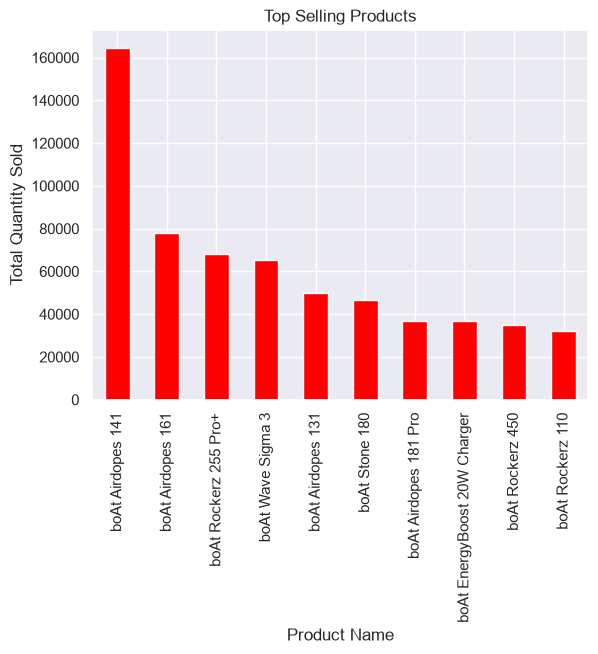

In [28]:
top_products = merged_df.groupby('ProductName')['Quantity'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar',color='red')
plt.xlabel('Product Name')
plt.ylabel('Total Quantity Sold')
plt.title('Top Selling Products')
plt.xticks(rotation=90)
plt.show()

### Analyze Revenue by Product Category
Groups the data by product `Category`, sums the `NetSales` to compute revenue per category, and visualizes the results using a blue bar chart.

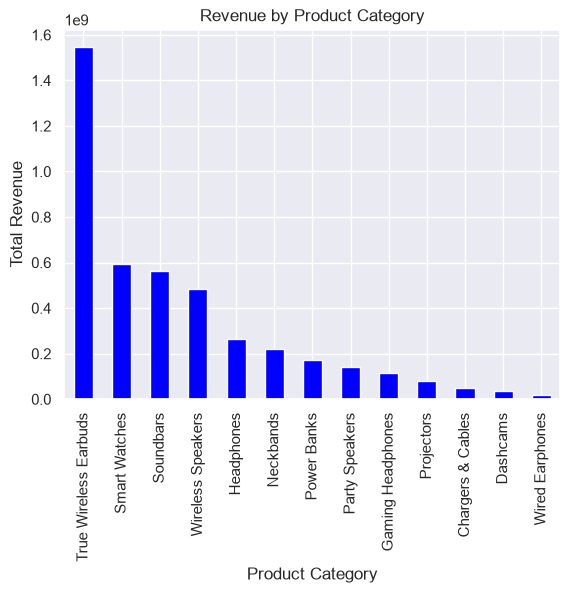

In [29]:
category_sales = merged_df.groupby('Category')['NetSales'].sum().sort_values(ascending=False)

category_sales.plot(kind='bar', color='blue')
plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.show()

### Analyze Customer Segment Contribution
Calculates the total revenue contribution of different customer segments and displays it using a pie chart showing percentage shares.

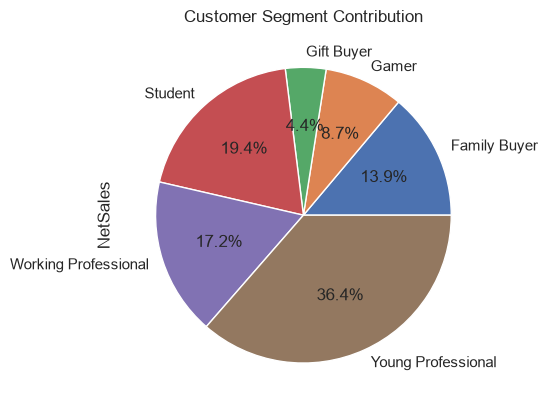

In [ ]:
segment_sales = merged_df.groupby('CustomerSegment')['NetSales'].sum()

segment_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title('Customer Segment Contribution')
plt.show()

### Analyze Top Revenue Generating Cities
Identifies and visualizes the top 10 cities generating the highest total revenue using a red bar chart.

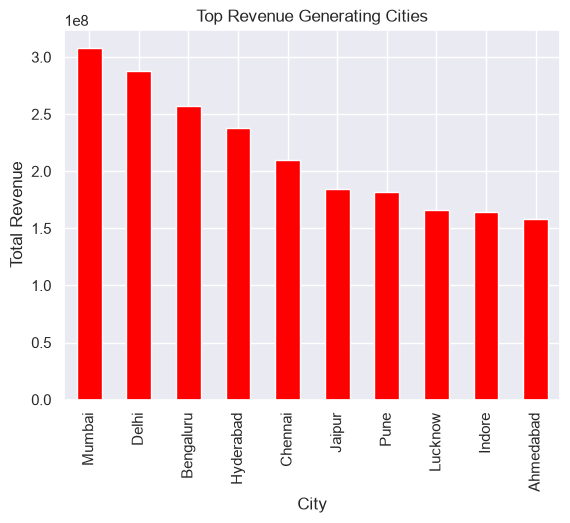

In [42]:
top_cities = merged_df.groupby('City')['NetSales'].sum().sort_values(ascending=False).head(10)

top_cities.plot(kind='bar',color='red')
plt.title('Top Revenue Generating Cities')
plt.xlabel('City')
plt.ylabel('Total Revenue')
plt.show()

### Analyze Online vs Offline Revenue
Aggregates and compares total revenue generated across different sales channels (`ChannelType_y`), plotting online versus offline sales.

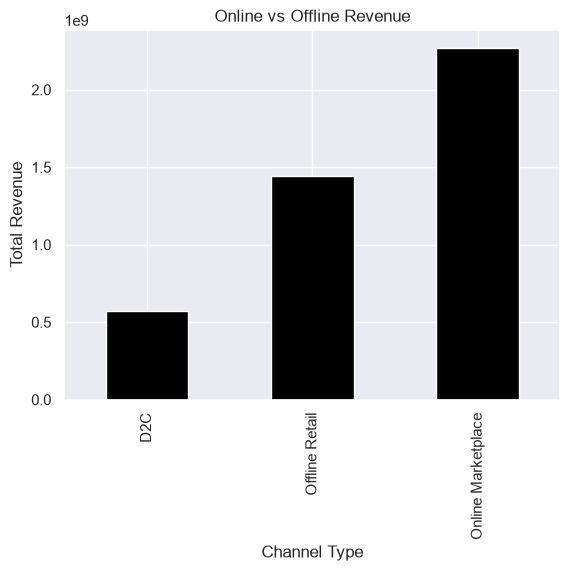

In [44]:
channel_type_sales = merged_df.groupby('ChannelType_y')['NetSales'].sum()

channel_type_sales.plot(kind='bar',color="black")
plt.xlabel('Channel Type')
plt.ylabel('Total Revenue')
plt.title('Online vs Offline Revenue')
plt.show()

### Analyze Festival vs Non-Festival Revenue
Compares total revenue during festival and non-festival periods to evaluate the impact of festive seasons on sales.

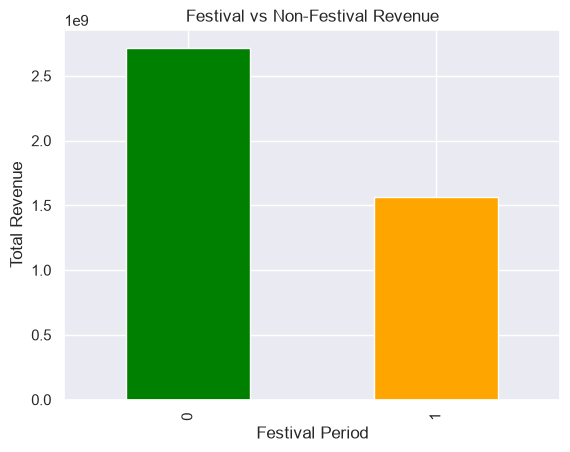

In [47]:
festival_sales = merged_df.groupby('IsFestivalPeriod')['NetSales'].sum()

festival_sales.plot(kind='bar', color=['green', 'orange'])
plt.title('Festival vs Non-Festival Revenue')
plt.xlabel('Festival Period')
plt.ylabel('Total Revenue')
plt.show()

### Analyze Revenue by Payment Method
Analyzes customer payment preferences by calculating and plotting total revenue generated by each payment method.

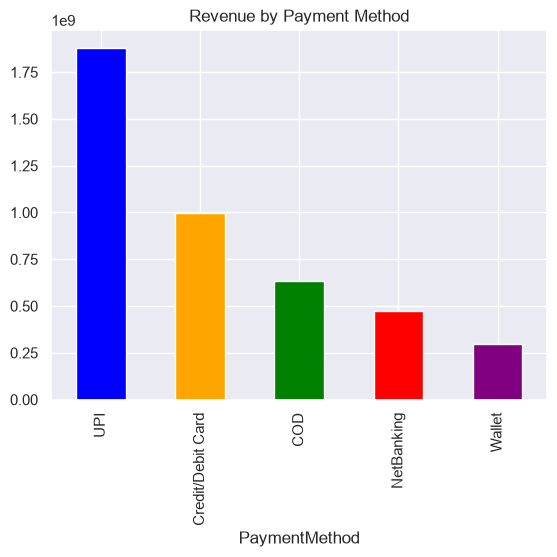

In [49]:
payment_analysis = merged_df.groupby('PaymentMethod')['NetSales'].sum()

payment_analysis.sort_values(ascending=False).plot(kind='bar',color=['blue', 'orange', 'green', 'red', 'purple'])
plt.title('Revenue by Payment Method')
plt.show()

### Analyze Order Status Distribution
Visualizes the distribution and frequency of different order statuses (e.g., Delivered, Returned, Cancelled) in the dataset.

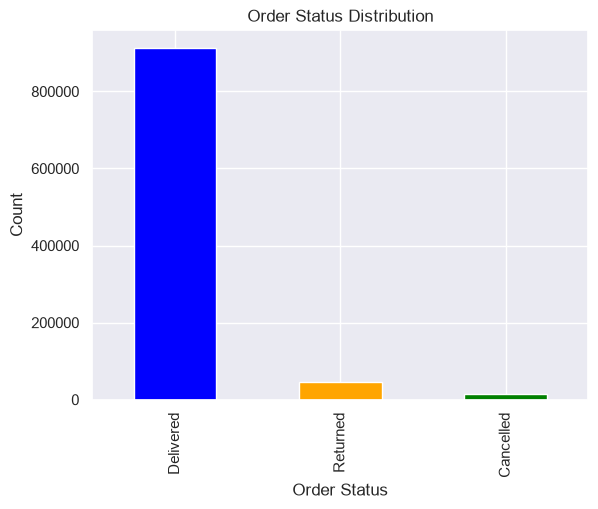

In [55]:
merged_df['OrderStatus'].value_counts().plot(kind='bar',color=['blue', 'orange', 'green'])

plt.title('Order Status Distribution')
plt.xlabel('Order Status')
plt.ylabel('Count')
plt.show()

### Analyze Top Return Reasons
Filters the records for returned products and plots a bar chart showing the most common reasons for customer returns.

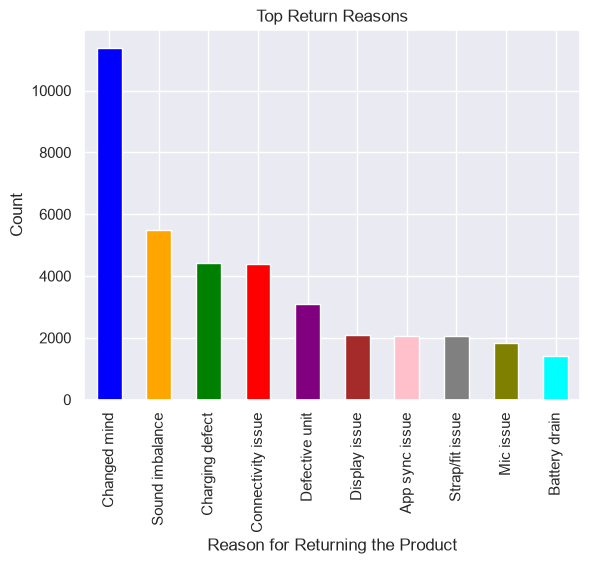

In [59]:
returns = merged_df[merged_df['ReturnReason'].notnull()]

returns['ReturnReason'].value_counts().head(10).plot(kind='bar',color=['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan'])

plt.title('Top Return Reasons')
plt.xlabel('Reason for Returning the Product')
plt.ylabel('Count')
plt.show()

### Analyze Average Delivery Time by Vehicle Type
Calculates the average delivery time (in days) for different vehicle types and visualizes the delivery performance.

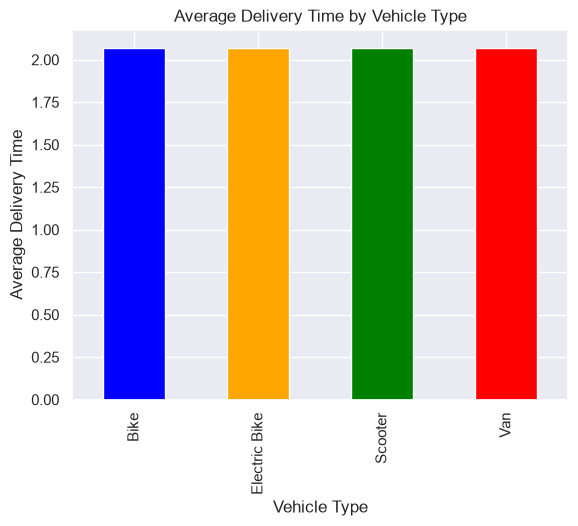

In [60]:
delivery_analysis = merged_df.groupby('VehicleType')['DeliveryDays'].mean()

delivery_analysis.plot(kind='bar',color=['blue', 'orange', 'green', 'red', 'purple'])

plt.title('Average Delivery Time by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Average Delivery Time')
plt.show()

### Analyze Profit by Product Category
Groups the dataset by product category, sums the profit for each, and plots a bar chart showing which categories are the most profitable.

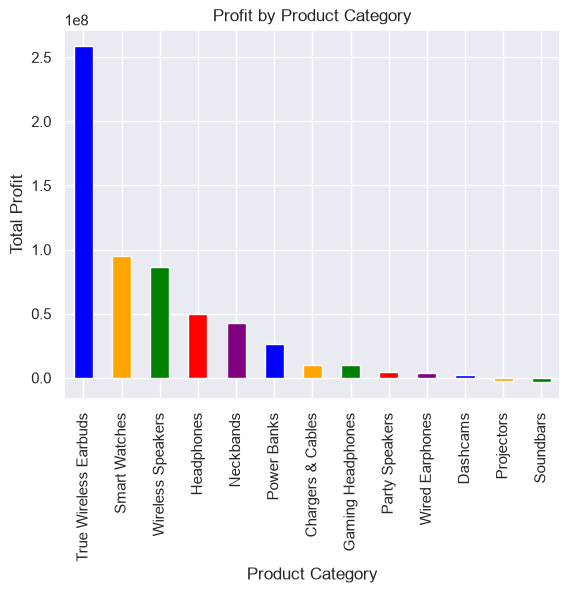

In [62]:
profit_category = merged_df.groupby('Category')['Profit'].sum()

profit_category.sort_values(ascending=False).plot(kind='bar',color=['blue', 'orange', 'green', 'red', 'purple'])

plt.title('Profit by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Profit')
plt.show()

### Analyze Monthly Revenue Trend
Groups the net sales by month and plots a line chart showing the overall trend of monthly revenue throughout the year.

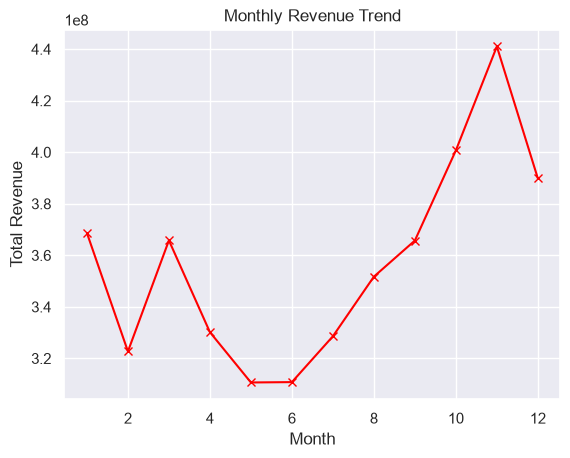

In [68]:
monthly_sales = merged_df.groupby('Month')['NetSales'].sum()

monthly_sales.plot(kind='line', marker='x', color='red')

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')

plt.show()

### Calculate Customer Lifetime Value (CLV)
Calculates the Customer Lifetime Value (CLV) by grouping net sales by `CustomerID` and sorting the customers in descending order of total spend.

In [69]:
clv = merged_df.groupby('CustomerID')['NetSales'].sum().sort_values(ascending=False)

### Analyze Sales by Hero Products
Groups net sales by `HeroFlag_y` to determine the revenue contribution of premium/hero products compared to regular products.

In [71]:
merged_df.groupby('HeroFlag_y')['NetSales'].sum()


HeroFlag_y
0    1.899706e+08
1    4.096257e+09
Name: NetSales, dtype: float64

### Analyze Weekend vs Weekday Sales
Groups net sales by `IsWeekend` to evaluate the revenue difference between weekend and weekday transactions.

In [72]:
merged_df.groupby('IsWeekend')['NetSales'].sum()

IsWeekend
0    3.014107e+09
1    1.272121e+09
Name: NetSales, dtype: float64

### Analyze Quantity Sold by Discount Percentage
Groups quantity sold by the discount percentage (`DiscountPct`) to analyze the relationship between discount levels and sales volume.

In [73]:
merged_df.groupby('DiscountPct')['Quantity'].sum()

DiscountPct
0.0400    2904
0.0401       6
0.0402      10
0.0403      11
0.0404       4
          ... 
0.7796       7
0.7797      17
0.7798      16
0.7799      11
0.7800    4867
Name: Quantity, Length: 7401, dtype: int64

# Key Business Insights

1. Online sales channels generated the majority of revenue.

2. Hero products contributed disproportionately high sales volume.

3. Festival periods significantly increased customer spending.

4. Certain customer segments showed higher average order value.

5. Delivery efficiency varied across regions and vehicle types.

6. Return rates were higher in selected product categories.

7. Discount-heavy transactions improved volume but reduced profit margins.